In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('DATASET/student_productivity_distraction_dataset_20000.csv')
df.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


# EDA - analiza exploratorie

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  str    
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  focus_score  

In [4]:
df.describe()

,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,23.00745,5.254562,6.517799,6.250479,4.003655,2.990177,2.988339,7.542400,249.654550,59.648050,9.494100,69.947435,5.478750,64.444350,70.266409,50.180419
std,5773.647028,3.75489,2.742876,2.029784,3.313082,2.305154,1.729815,1.732803,4.016231,143.711231,34.611751,5.801469,17.397431,2.866943,20.176114,17.282277,16.086666
min,1.000000,17.00000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,5000.750000,20.00000,2.900000,4.770000,3.380000,2.000000,1.487500,1.490000,4.000000,125.000000,30.000000,4.000000,54.810000,3.000000,47.000000,55.460000,38.700000
50%,10000.500000,23.00000,5.250000,6.510000,6.240000,4.010000,2.980000,2.970000,8.000000,249.000000,60.000000,9.000000,69.985000,5.000000,65.000000,70.315000,50.235000
75%,15000.250000,26.00000,7.640000,8.310000,9.102500,5.970000,4.480000,4.490000,11.000000,373.000000,90.000000,15.000000,85.050000,8.000000,82.000000,85.340000,61.782500
max,20000.000000,29.00000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


In [5]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day', 'sleep_hours',
       'phone_usage_hours', 'social_media_hours', 'youtube_hours',
       'gaming_hours', 'breaks_per_day', 'coffee_intake_mg',
       'exercise_minutes', 'assignments_completed', 'attendance_percentage',
       'stress_level', 'focus_score', 'final_grade', 'productivity_score'],
      dtype='str')

target: productivity_score 

### Studiul influenteaza productivitatea?

<Axes: xlabel='study_hours_per_day', ylabel='productivity_score'>

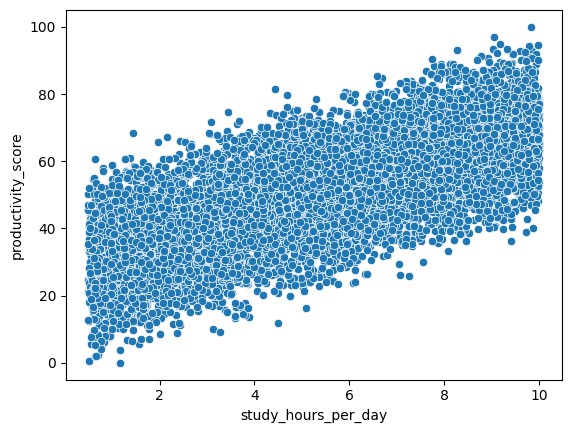

In [6]:
df_sample = df.sample(10000)
sns.scatterplot(x='study_hours_per_day', y='productivity_score', data=df_sample)

Timpul de invatare al studentului este important

<Axes: xlabel='final_grade', ylabel='productivity_score'>

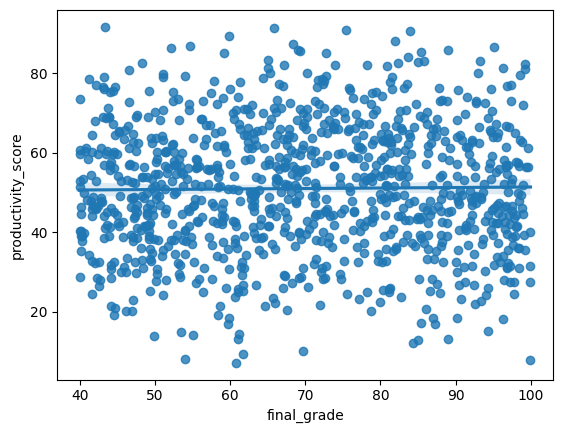

In [7]:
df_sample = df.sample(1000)
sns.regplot(x='final_grade', y='productivity_score', data=df_sample)

final_grade nu are o corelatie buna cu productivity_score, adica nota obtinuta de un student nu influenteata productivitatea acestuia, adica nota finala NU ESTE un predictor bun pentru productivitate.

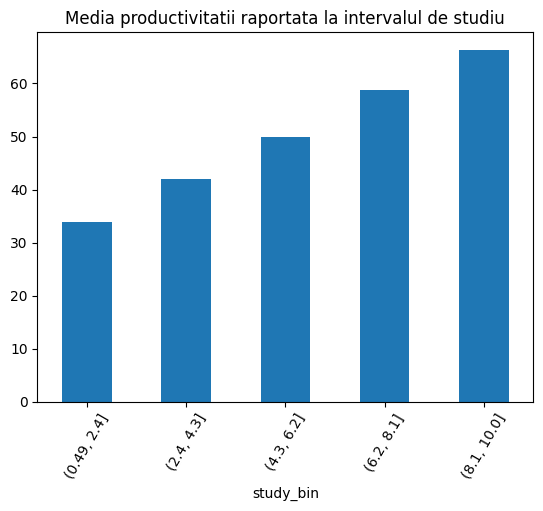

In [8]:
df['study_bin'] = pd.cut(df['study_hours_per_day'], bins=5)

df.groupby('study_bin')['productivity_score'].mean().plot(kind='bar')
plt.title("Media productivitatii raportata la intervalul de studiu")
plt.xticks(rotation=60)
plt.show()

Inca o data s-a demonstrat ca timpul petrecut invatand este direct proportional cu productivity_score, adica pe masura ce studentul invata mai multe ore pe zi, acesta isi creste implicit si scorul de productivitate, care se va materializa in rezultate mai bune.

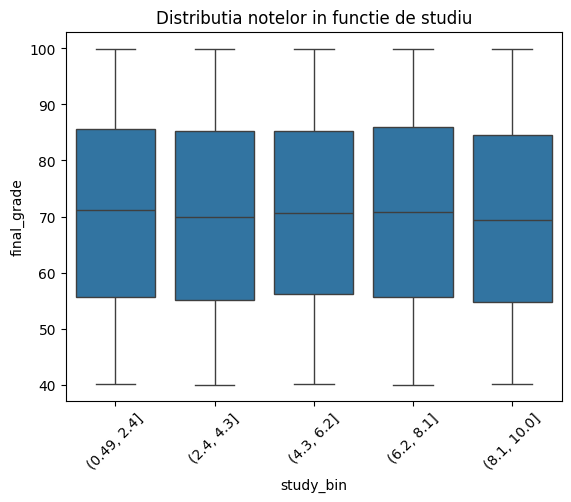

In [9]:
sns.boxplot(x='study_bin', y='final_grade', data=df)
plt.xticks(rotation=45)
plt.title("Distributia notelor in functie de studiu")
plt.show()

### Social media influenteaza nota finala?

<Axes: xlabel='social_media_hours', ylabel='productivity_score'>

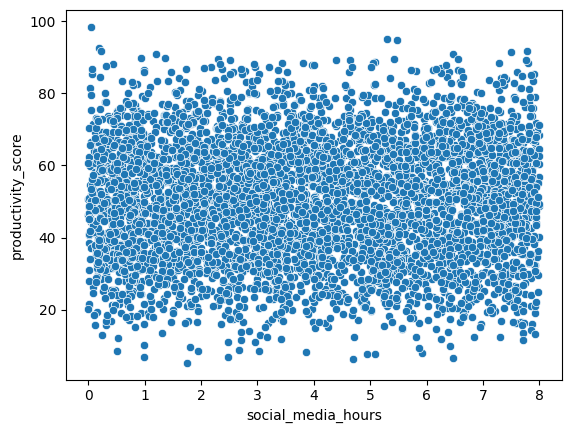

In [10]:
df_sample = df.sample(5000)

sns.scatterplot(
    x='social_media_hours',
    y='productivity_score',
    data=df_sample,
)

Orele petrecute pe social media nu influenteaza productivity_score in mare masura!!
DE CE? pentru ca am luat diferite sample-uri, de dimensiuni tot mai mari, iar distributia punctelor a ramas destul de omogena
Se confirma acest lucru si prin matricea de corelatie de mai jos.

### Heatmap corelatie

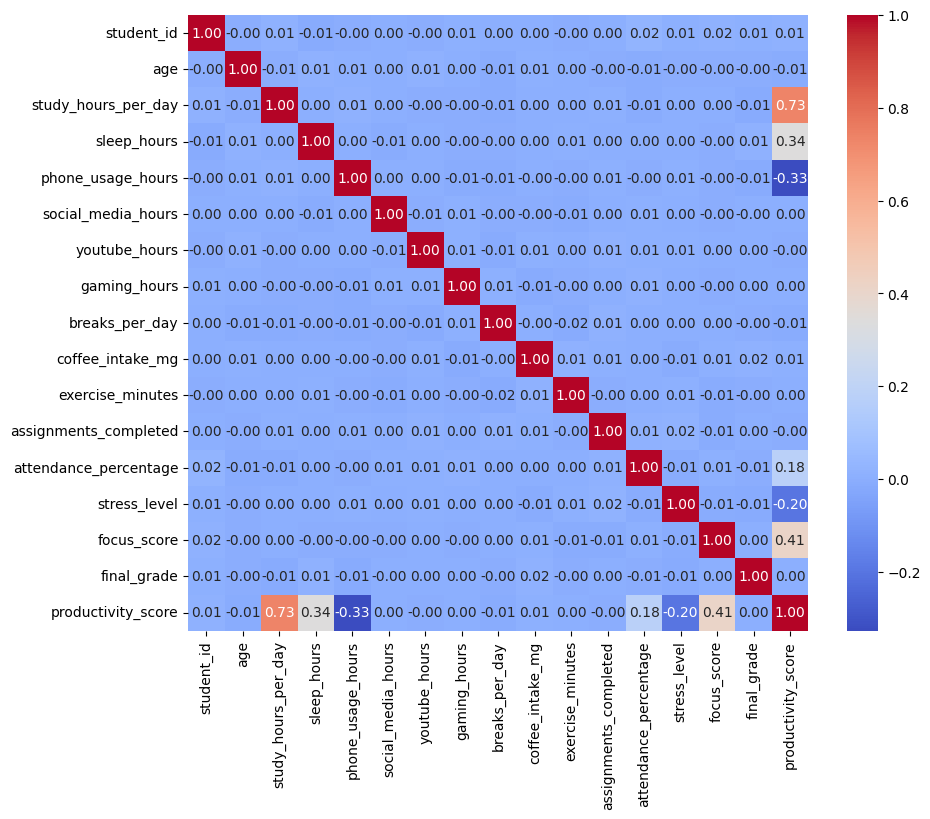

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [12]:
df.isnull().sum()

student_id               0
age                      0
gender                   0
study_hours_per_day      0
sleep_hours              0
phone_usage_hours        0
social_media_hours       0
youtube_hours            0
gaming_hours             0
breaks_per_day           0
coffee_intake_mg         0
exercise_minutes         0
assignments_completed    0
attendance_percentage    0
stress_level             0
focus_score              0
final_grade              0
productivity_score       0
study_bin                0
dtype: int64

Nu exista valori lipsa hehe

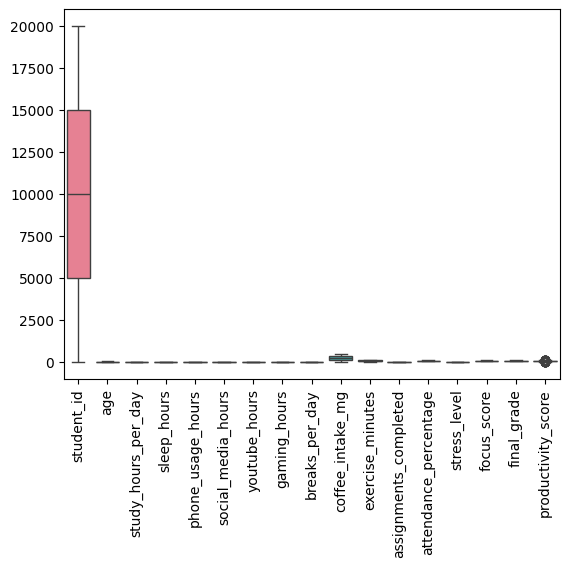

In [13]:
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

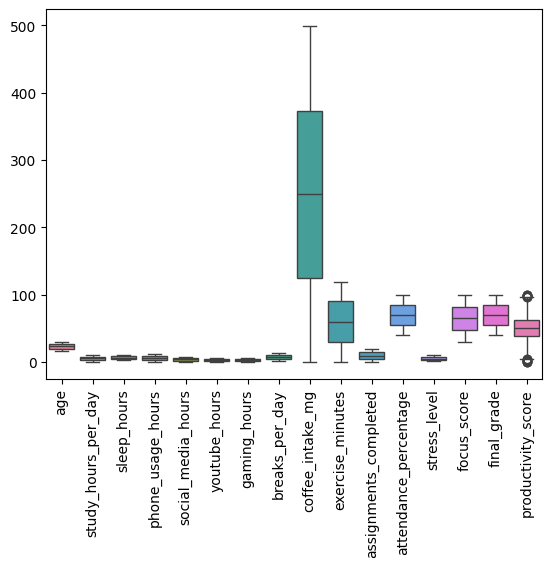

In [14]:
df_no_id = df.drop(columns=['student_id'])

sns.boxplot(data=df_no_id)
plt.xticks(rotation=90)
plt.show()

# Curatare date
Transformare coloana 'gender' care e string in alte 3 coloane, numerice: is_male, is_female, is_other

In [15]:
df['gender'] = df['gender'].str.lower().str.strip()

# creez noile coloane cu valori numerice
df['is_male'] = (df['gender'] == 'male').astype(int)
df['is_female'] = (df['gender'] == 'female').astype(int)
df['is_other'] = (df['gender'] == 'other').astype(int)

In [16]:
df.head

<bound method NDFrame.head of        student_id  age  gender  study_hours_per_day  sleep_hours  \
0               1   23  female                 4.35         3.63   
1               2   20    male                 6.14         6.58   
2               3   29  female                 4.98         3.26   
3               4   27  female                 3.19         4.58   
4               5   24    male                 7.67         6.21   
...           ...  ...     ...                  ...          ...   
19995       19996   26  female                 4.81         7.83   
19996       19997   22   other                 0.83         4.49   
19997       19998   25    male                 9.36         4.33   
19998       19999   22  female                 0.74         4.44   
19999       20000   19  female                 3.64         6.35   

       phone_usage_hours  social_media_hours  youtube_hours  gaming_hours  \
0                   3.38                2.73           1.83          5.26   

In [17]:
#sterg coloana veche gender, care e string
df.drop(columns=['gender'], inplace=True)


In [18]:
df.columns

Index(['student_id', 'age', 'study_hours_per_day', 'sleep_hours',
       'phone_usage_hours', 'social_media_hours', 'youtube_hours',
       'gaming_hours', 'breaks_per_day', 'coffee_intake_mg',
       'exercise_minutes', 'assignments_completed', 'attendance_percentage',
       'stress_level', 'focus_score', 'final_grade', 'productivity_score',
       'study_bin', 'is_male', 'is_female', 'is_other'],
      dtype='str')

# Feature engineering
INGINERIA CARACTERISTICILOR

## 1. total_screen_time=gaming_hours + phone_usage_hours
- reprezinta timpul total petrecut pe activitati digitale care nu sunt cu scop academic(social media, youtube, gaming si utilizarea telefonului). Social media si youtube le-am considerat incluse in timpul de utilizare telefon, iar timpul de gaming ramane individual. Deci, total screen time va fi suma dintre gaming si phone_usage hours.
Permite modelului sa inteleaga mai bine nivelul de distragere al studentului si impactul avut asupra productivitatii. 

In [19]:
df["total_screen_time"] =df["gaming_hours"] + df["phone_usage_hours"]

print("=== total_screen_time ===")
print(df['total_screen_time'].describe())
print(f"Corelatie cu nota finala: {df['total_screen_time'].corr(df['final_grade']):.4f}")

print(f"Corelatie cu productivitatea: {df['total_screen_time'].corr(df['productivity_score']):.4f}")

=== total_screen_time ===
count    20000.000000
mean         9.238818
std          3.727337
min          0.550000
25%          6.380000
50%          9.290000
75%         12.090000
max         17.860000
Name: total_screen_time, dtype: float64
Corelatie cu nota finala: -0.0096
Corelatie cu productivitatea: -0.2900


In [20]:
#verificare coloana noua
df[["gaming_hours", "phone_usage_hours", "total_screen_time"]].head(10)

,gaming_hours,phone_usage_hours,total_screen_time
0,5.26,3.38,8.64
1,1.73,5.48,7.21
2,4.71,4.83,9.54
3,2.52,10.06,12.58
4,5.65,3.02,8.67
5,0.16,4.02,4.18
6,4.44,11.45,15.89
7,5.13,3.31,8.44
8,3.38,9.66,13.04
9,2.55,2.13,4.68


## 2. study_efficiency = study_hours / total_screen_time
- reprezinta eficienta invatarii studentului prin raportul dintre orele de studiu si timpul total petrecut pe ecran 

In [21]:
df["study_efficiency"] = df["study_hours_per_day"] / (df["total_screen_time"] + 1)

print("=== study_efficiency ===")
print(df['study_efficiency'].describe())
print(f"Corelatie cu nota finala: {df['study_efficiency'].corr(df['final_grade']):.4f}")

print(f"Corelatie cu productivitatea: {df['study_efficiency'].corr(df['productivity_score']):.4f}")

=== study_efficiency ===
count    20000.000000
mean         0.615472
std          0.493450
min          0.030451
25%          0.281953
50%          0.512801
75%          0.790140
max          5.738372
Name: study_efficiency, dtype: float64
Corelatie cu nota finala: 0.0036
Corelatie cu productivitatea: 0.6392


## 3. lifestyle_quality = sleep_hours * 0.6 + exercise_hours * 0.4
- reprezinta calitatea stilului de viata si influenta avuta asupra rezultatelor studentului

In [22]:
df["lifestyle_quality"] = df["sleep_hours"] * 0.6 / (df["total_screen_time"] * 0.4)

print("=== lifestyle_quality ===")
print(df['lifestyle_quality'].describe())
print(f"Corelatie cu nota finala: {df['lifestyle_quality'].corr(df['final_grade']):.4f}")

print(f"Corelatie cu productivitatea: {df['lifestyle_quality'].corr(df['productivity_score']):.4f}")

=== lifestyle_quality ===
count    20000.000000
mean         1.375737
std          1.193324
min          0.257576
25%          0.733546
50%          1.058095
75%          1.578708
max         21.435484
Name: lifestyle_quality, dtype: float64
Corelatie cu nota finala: 0.0162
Corelatie cu productivitatea: 0.3020


In [23]:
df.head(5)

,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,...,focus_score,final_grade,productivity_score,study_bin,is_male,is_female,is_other,total_screen_time,study_efficiency,lifestyle_quality
0,1,23,4.35,3.63,3.38,2.73,1.83,5.26,6,347,...,57,81.87,33.78,"(4.3, 6.2]",0,1,0,8.64,0.451245,0.630208
1,2,20,6.14,6.58,5.48,1.51,3.13,1.73,13,403,...,49,60.90,48.99,"(4.3, 6.2]",1,0,0,7.21,0.747868,1.368932
2,3,29,4.98,3.26,4.83,3.63,0.18,4.71,1,419,...,38,86.22,36.60,"(4.3, 6.2]",0,1,0,9.54,0.472486,0.512579
3,4,27,3.19,4.58,10.06,3.95,5.75,2.52,9,178,...,50,71.77,19.87,"(2.4, 4.3]",0,1,0,12.58,0.234904,0.546105
4,5,24,7.67,6.21,3.02,1.59,5.46,5.65,8,436,...,41,90.13,52.90,"(6.2, 8.1]",1,0,0,8.67,0.793175,1.074394


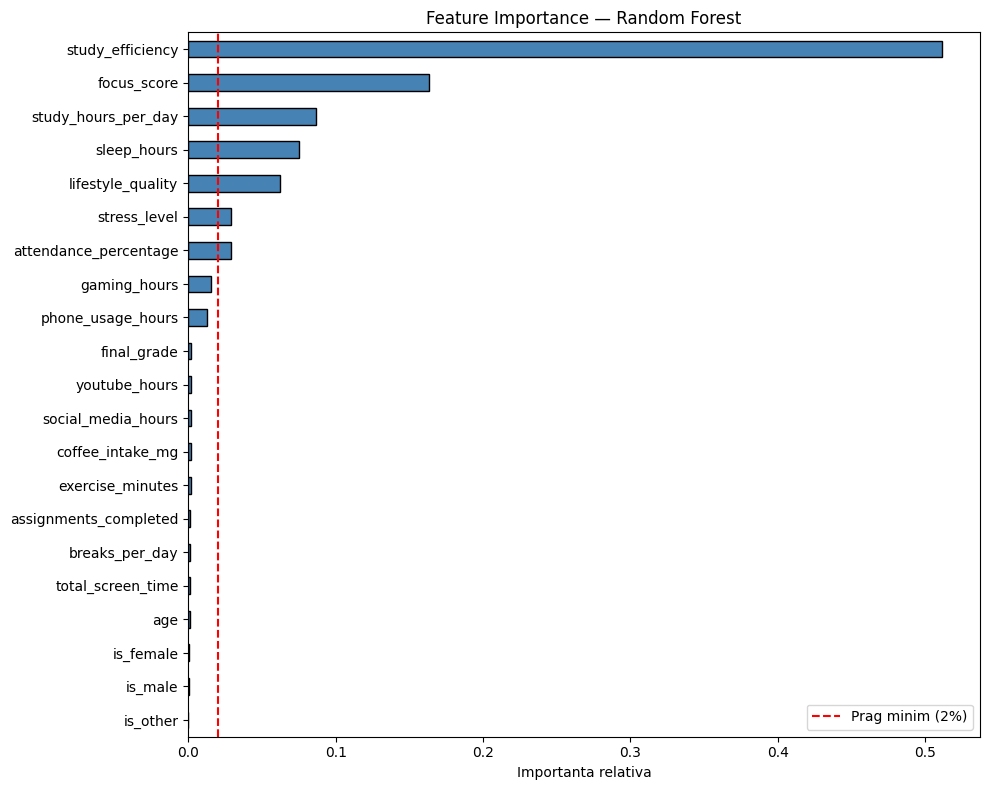

In [24]:
from sklearn.ensemble import RandomForestRegressor

# separare date
X = df.drop("productivity_score", axis=1)
y = df["productivity_score"]

#elimin din grafic coloanele care am vazut ca nu au importanta in rularea precedenta
X = X.drop(columns=['student_id', 'study_bin'])

#detecteaza si converteste coloanele de tip interval, in media intervalului,
# pentru ca sa nu mai primesc eroare-la random forest ii trebuie date numerice, nu intervale
for col in X.columns:
    # cand dtype este explicit IntervalDtype
    if isinstance(X[col].dtype, pd.IntervalDtype):
        X[col] = X[col].apply(lambda x: x.mid if pd.notnull(x) else np.nan)
    # cand dtype este object, dar contine Interval
    elif X[col].dtype == object:
        first_valid = X[col].dropna().iloc[0] if not X[col].dropna().empty else None
        if isinstance(first_valid, pd.Interval):
            X[col] = X[col].apply(lambda x: x.mid if pd.notnull(x) else np.nan)

# convertesc tot ce ar putea ramane pe dinafara, la numeric
X = X.apply(pd.to_numeric, errors='coerce')

# model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# importanta
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importanta relativa')
plt.axvline(x=0.02, color='red', linestyle='--', label='Prag minim (2%)')
plt.legend()
plt.tight_layout()
plt.show()

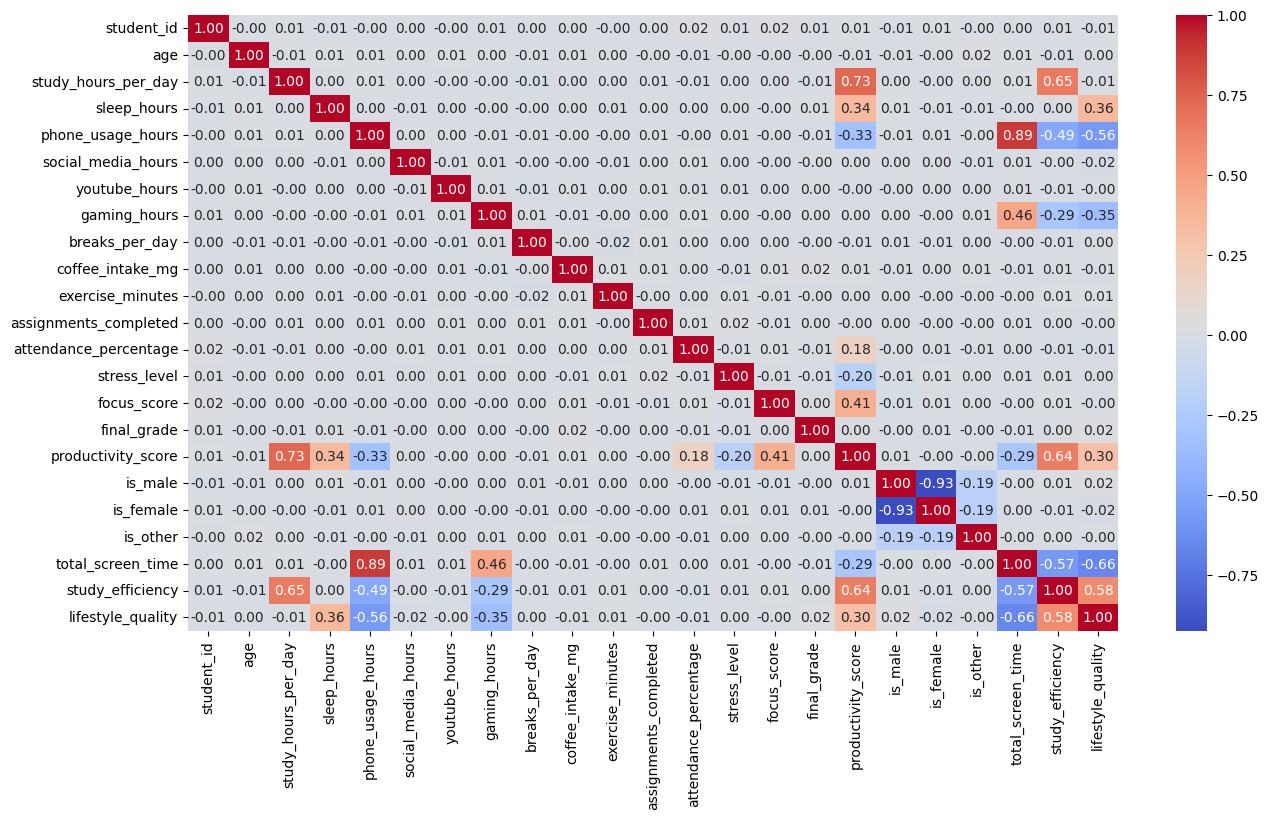

In [25]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

## CONCLUZII din matricea de corelatie:
* pastrez toate cele 3 features, deoarece au corelatie buna
* pot elimina SIGUR coloanele srudent_id, age, is_male, is_female, is_other


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

#date train si test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#antrenare pe train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#orezicere pe test
y_pred = model.predict(X_test)

# Metrici
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE  (eroare medie absolută): {mae:.2f}")
print(f"RMSE (eroare pătratică medie): {rmse:.2f}")
print(f"R2   (coeficient determinare): {r2:.4f}")

MAE  (eroare medie absolută): 2.02
RMSE (eroare pătratică medie): 2.55
R2   (coeficient determinare): 0.9748


In [27]:
df = df.drop(columns=['student_id', 'age', 'is_male', 'is_female', 'is_other'])

In [28]:
print(df.columns)

Index(['study_hours_per_day', 'sleep_hours', 'phone_usage_hours',
       'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day',
       'coffee_intake_mg', 'exercise_minutes', 'assignments_completed',
       'attendance_percentage', 'stress_level', 'focus_score', 'final_grade',
       'productivity_score', 'study_bin', 'total_screen_time',
       'study_efficiency', 'lifestyle_quality'],
      dtype='str')


### Am eliminat coloanele care nu aveau influentaa asupra variabilei target(productivity_score), iar acum verific iar matricea de corelatie

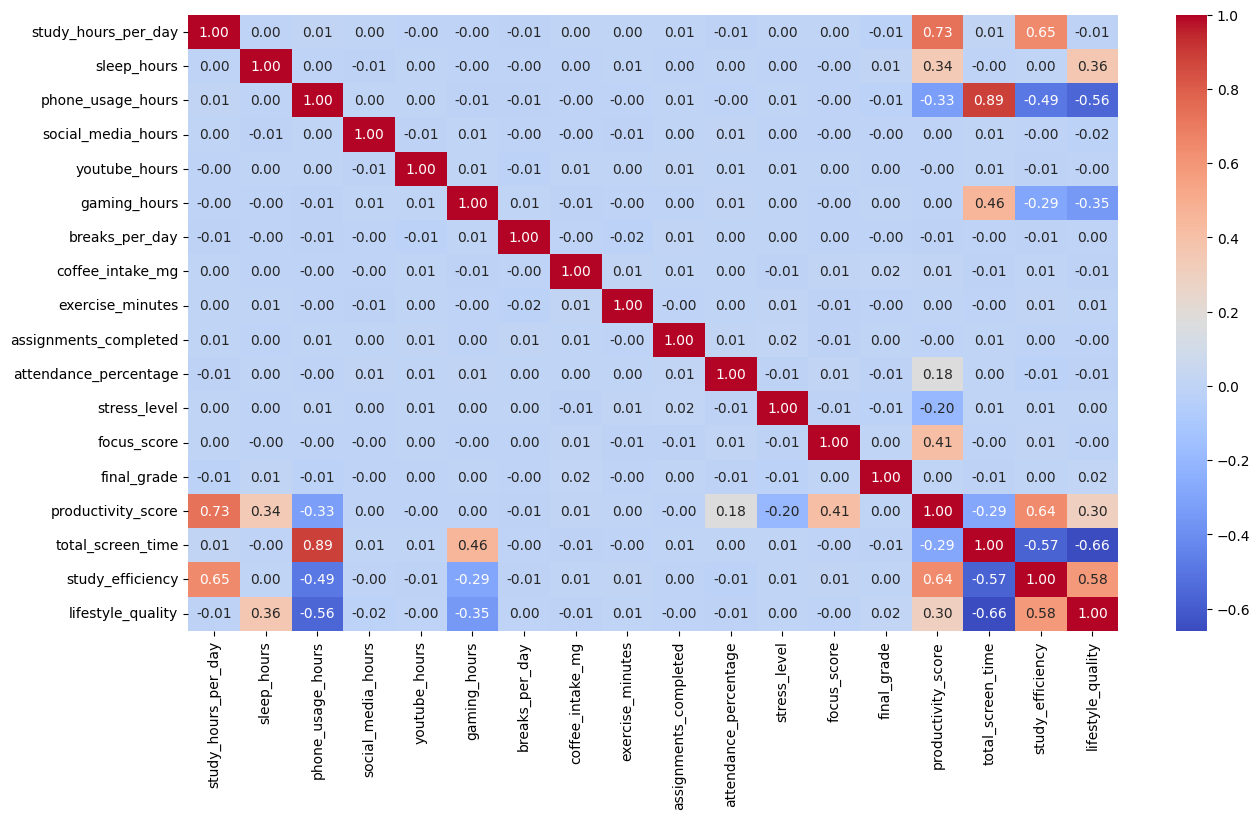

In [29]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

### Bun, acum mai elimin coloane care nu au mare influenta asupra productivity_score:
* breaks_per_day
* coffee_intake_mg
* exercise_minutes
* assignments_completed

In [30]:
df = df.drop(columns=['breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed'])

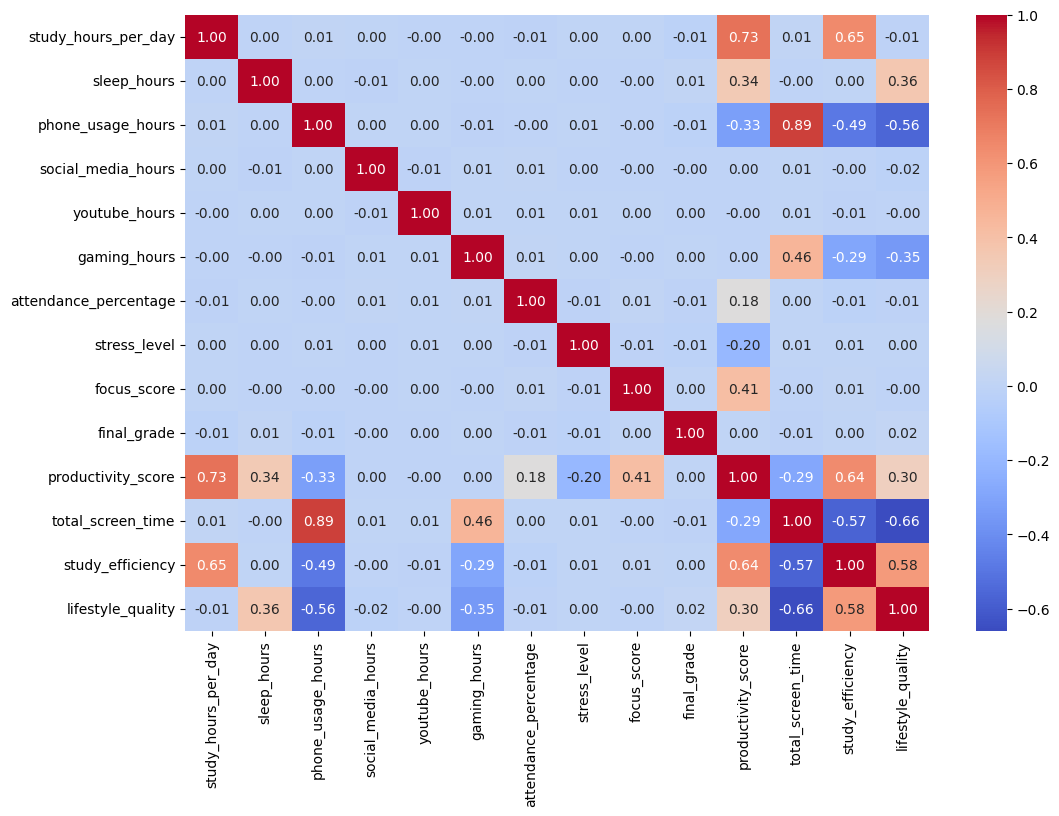

In [31]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()